# Last week

## Partial equilibrium

- **Example 1: Consumption & labor supply (lecture)**

    Numerical solution:
    
    - Minimizer applied to objective function
    - Root-finder applied to first-order condition

- **Example 2: Consumption-savings choice (workshop)**

    Numerical solution:

    - Minimizer applied to objective function

***
# General equilibrium

## Consumption & labor supply

### Household problem (representative household)

- Household problem:
  $$
  \begin{aligned}
  \max_{c,~ h} \enskip& 
    \Biggl\{
        \underbrace{\frac{c^{1-\gamma} - 1}{1-\gamma}}_{\text{Utility from cons.}} 
        - 
        \underbrace{\psi \frac{h^{1+1/\theta}}{1+1/\theta}}_{\text{Disutility from work}}
    \Biggr\}\\
    \text{subject to} \quad  c &= r \cdot a + w\cdot h \\
        c &\geq 0\;, h \geq 0
  \end{aligned}
  $$

- Choice variables:

    -   $c$: Consumption
    -   $h$: Hours worked

- Parameters:

    -   $\gamma$: Relative risk aversion
    -   $\psi$: Weight on disutility of work
    -   $\theta$: Labor supply elasticity
    -   $a$: Initial assets

- Prices (taken as given, competitive equilibrium):

    -   $r$: Interest rate (return on capital)
    -   $w$: Wage rate

***
### Firm problem (representative firm)

- Firm problem:
    $$
    \max_{K,~L} \enskip \Pi = 
        \underbrace{z K^{\alpha} L^{1-\alpha}}_{\text{Output } Y}
         - \underbrace{r K}_{\text{Cost of capital}} 
         - \underbrace{w L}_{\text{Cost of labor}}
    $$

- Choice variables:

    - $K$: Capital
    - $L$: Labor

- Parameters:

    - $\alpha$: Capital share (or elasticity with respect to capital)
    - $z$: Total factor productivity (TFP)

- Prices (taken as given, competitive equilibrium):

    -   $r$: Return on capital
    -   $w$: Wage rate

- First-order conditions:
    $$
    \begin{aligned}
    r &= \alpha z \left(\frac{K}{L}\right)^{\alpha-1} = \alpha z k^{\alpha-1} \\
    w &= (1-\alpha) z\left(\frac{K}{L}\right)^{\alpha} = (1-\alpha) z k^{\alpha}
    \end{aligned}
    $$
    where $k \equiv \frac{K}{L}$ is the capital-labor ratio.

- Labor demand:
    <a id='ls-firm-L'></a>
    $$
    L = \left( \frac{w}{(1-\alpha) z} \right)^{-\frac{1}{\alpha}}K
        \tag{1.1}
    $$


***
### Equilibrium

Quantities $(K,L,Y,c,h)$ and prices $(r,w)$ such that:

- Asset market: $K = a$ (capital $K$ demanded by firms equals savings $a$ supplied by households).
- Labor market: $L = h$ (labor $L$ demanded by firms equals hours $h$ supplied by households).
- Goods market: $Y = c$ (aggregate output $Y$ equals the amount of goods $c$ consumed by households).

***
### Analytical solution

- This problem is simple enough to be solved analytically:
    $$
    h = L = \left[ \frac{(1-\alpha)\left(z a^{\alpha}\right)^{1-\gamma}}{\psi} 
        \right]^{\frac{1}{1/\theta + \alpha + \gamma - \alpha \gamma}}
    $$

***
### Numerical solution

- General rule: solve as much as possible analytically (we ignore this here)

- **Firm problem:** use first-order conditions

- **Household problem:** usually solved via minimizer (or other methods)

- **Equilibrium:** usually solved via root-finder (zero excess demand)

#### Solution algorithm


1.  Define parameters.

2.  Write function to solve the household problem for given $(w, r)$ which returns 
    the **optimal labor supply $h$** (use a minimizer).

3.  Write function to solve the firm problem for given $w$ which returns the **firm labor demand $L$** 
    (use the firm's first-order conditions).

4.  Write function $f(w)$ which returns the **excess labor demand** for a given $w$, defined 
    as $L - h$.

    Use the functions from steps (2) and (3) to compute $h$ and $L$.
    
5.  Make an initial guess for the equilibrium wage rate $w_0$ and call the root finder
    to locate the root $w^*$ of $f$, $f(w^*) = 0$.

6.  Compute and store all other equilibrium quantities and prices for given $w^*$.

#### Implementation

- See [lecture06_labor.py](lecture06_labor.py) for full implementation

In [1]:
# Enable automatic reloading of external modules
%load_ext autoreload
%autoreload 2

##### Step 1: Define parameters

- Recall how we used to define functions with each parameter as separate argument
- This becomes tedious as the number of parameters grows
- Replace with single `Parameters` class

In [2]:
# Relative risk aversion
gamma = 2.0
# Weight on disutility of work
psi = 1.0
# Labor supply elasticity
theta = .5
# Initial assets
a = 5.0
# TFP in the production function
z = 1.0
# Capital share in output
alpha = .36

In [3]:
# TODO: Define Parameters class to store model parameters

from dataclasses import dataclass

@dataclass
class Parameters:
    """
    Container for model parameters
    """
    alpha: float = .36          # Capital share in output
    z: float = 1.0              # TFP
    gamma: float = 2.0          # Relative risk aversion
    psi: float = 1.0            # Weight on disutility of work
    theta: float = .5           # Labor supply elasticity
    a: float = 5.0              # Initial assets

In [4]:
# TODO: Create instance of Parameters
par = Parameters()

In [8]:
# Experiment with alternative parameters
par2 = Parameters(gamma = 1.0)
par2

Parameters(alpha=0.36, z=1.0, gamma=1.0, psi=1.0, theta=0.5, a=5.0)

In [ ]:
# Change gamma in place
par2.gamma = 3.0

In [ ]:
import numpy as np


def util(c, h, gamma, psi, theta):
    """
    Compute the utility of a given consumption/labor supply choice.

    Parameters
    ----------
    c : float or array
        Consumption level.
    h : float or array
        Hours worked.
    gamma : float
        Relative risk aversion parameter.
    psi : float
        Weight on disutility of labor.
    theta : float
        Labor supply elasticity.

    Returns
    -------
    u : float or array
        Utility value.
    """

    # Consumption utility
    if gamma == 1:
        # Log utility
        u = np.log(c)
    else:
        # General CRRA utility
        u = (c ** (1 - gamma) - 1) / (1 - gamma)

    # add disutility of labor
    u -= psi * h ** (1 + 1 / theta) / (1 + 1 / theta)

    return u

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Rewrite the <TT>util()</TT> function from above so that it accepts a single <TT>par</TT> argument
of type <TT>Parameters</TT> instead of individual <TT>gamma</TT>, <TT>psi</TT>, and <TT>theta</TT>.

</div>
<span style="display: none;">YourTurnEnd</span>

In [18]:
def util(c, h, par: Parameters):
    """
    Compute the utility of a given consumption/labor supply choice.

    Parameters
    ----------
    c : float or array
        Consumption level.
    h : float or array
        Hours worked.
    par: Parameters
        Instance of Parameters class

    Returns
    -------
    u : float or array
        Utility value.
    """

    # Consumption utility
    if par.gamma == 1:
        # Log utility
        u = np.log(c)
    else:
        # General CRRA utility
        u = (c ** (1 - par.gamma) - 1) / (1 - par.gamma)

    # add disutility of labor
    u -= par.psi * h ** (1 + 1 / par.theta) / (1 + 1 / par.theta)

    return u

##### Step 2: Solving the household problem

- Use [L-BFGS-B minimizer](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-lbfgsb.html) 
from 
`scipy.optmize` module.
- Minimize over choice variable $h$
- Need to specify bounds $h \geq 0$

In [19]:
from scipy.optimize import minimize

def solve_hh(r, w, par: Parameters):
    """
    Solve household problem for given prices and parameters

    Parameters
    ----------
    r : float
        Return on capital
    w : float
        Wage rate
    par : Parameters
        Parameters for given problem

    Returns
    -------
    c_opt : float
        Optimal consumption choice
    h_opt : float
        Optimal hours choice
    """

    # Step 1: define bounds for the choice of h
    bounds = ((0, None), )

    # Initial guess for h
    h_guess = 0.5

    # Call a MINIMIZER and save result object
    res = minimize(
        lambda h: -util(r * par.a + w * h, h, par),
        x0=h_guess,
        bounds=bounds
    )

    if not res.success:
        print('Minimizer exited without success')
        print(res.message)

    # Recover optimal values from result
    h_opt = res.x[0]

    # Optimal consumption: from BC
    c_opt = r * par.a + w * h_opt

    return c_opt, h_opt

In [20]:
solve_hh(r=.04, w=1.0, par=par)

(np.float64(1.104987555247004), np.float64(0.904987555247004))

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Plot the optimal hours <i>h</i> returned by <tt>solve_hh()</tt> 
for <tt>w</tt> on the interval [0.5, 2]. Fix the interest rate at <i>r=0.1</i> for this exercise. Does the shape intuitively make sense?
</div>
<span style="display: none;">YourTurnEnd</span>

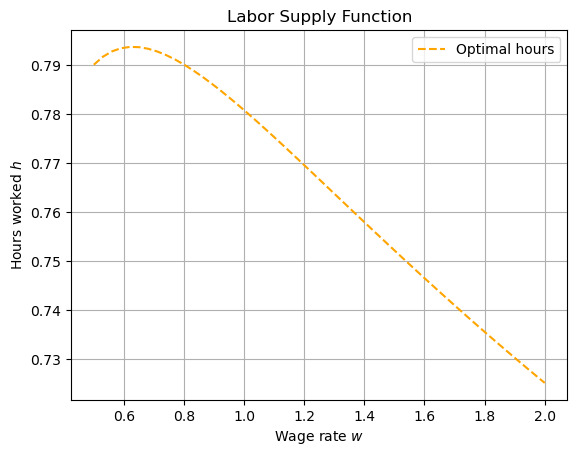

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# initial parameters (variable)
r = .1
wages = np.linspace(.5, 2, 51)

# Initial empty array for optimal hours (can also do empty list and append without enumerate(wages))
h_opt_array = np.empty_like(wages)

for i, w in enumerate(wages):
    c_opt, h_opt = solve_hh(r, w=w, par=par)
    h_opt_array[i] = h_opt


plt.plot(wages, h_opt_array, label='Optimal hours', c='orange', ls='--', lw=1.5)
plt.xlabel('Wage rate $w$')
plt.ylabel('Hours worked $h$')
plt.title('Labor Supply Function')
plt.grid()

_ = plt.legend()

##### Step 3: Solving the firm problem

-   Compute firm labor demand from [(1.1)](#ls-firm-L):
    $$
    L = \left( \frac{w}{(1-\alpha) z} \right)^{-\frac{1}{\alpha}}K
        \tag{1.1}
    $$
-   Additionally return output $Y$ and interest rate $r$ for later use

In [36]:
def solve_firm(w, par: Parameters):
    """
    Return the solution to the firm's problem for given wage rate and parameters.

    Parameters
    ----------
    w : float
        Wage rate
    par : Parameters
        Parameters for given problem

    Returns
    -------
    L : float
        Firm labor demand
    Y : float
        Firm output
    r : float
        Interest rate implied by wage rate

    """

    # Determine K from asset market clearing (K = a)
    K = par.a

    # Compute optimal labor demand L
    L = (w / (1 - par.alpha) / par.z) ** (- 1 / par.alpha) * K

    # Capital output ratio
    k = K / L

    # Compute interest rate r implied by K and L
    r = par.alpha * par.z * k ** (par.alpha - 1)

    # Output 
    Y = par.z * K**par.alpha * L**(1 - par.alpha)

    return L, Y, r

In [37]:
solve_firm(w=.5, par=par)

(9.926027534439934, 7.754709011281197, 0.5583390488122463)

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Plot the firm's optimal labor demand <i>L</i> returned by <tt>solve_firm()</tt> 
for <tt>w</tt> on the interval [0.5, 2]. Does the shape intuitively make sense?
</div>
<span style="display: none;">YourTurnEnd</span>

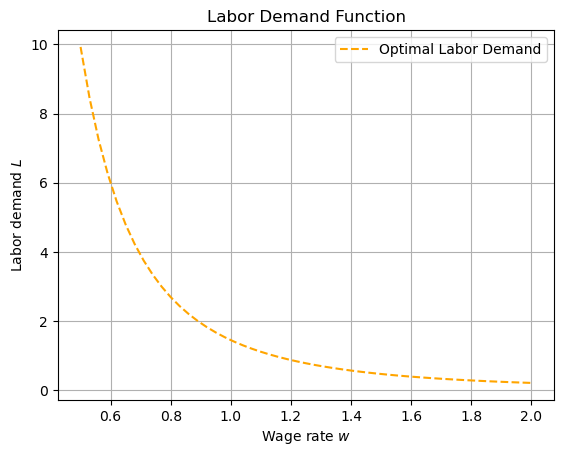

In [39]:
wages = np.linspace(.5, 2, 51)

labor = np.empty_like(wages)

for i, w in enumerate(wages):
    L, *rest = solve_firm(w=w, par=par)
    labor[i] = L

plt.plot(wages, labor, c='orange', ls='--', lw=1.5, label='Optimal Labor Demand')
plt.xlabel('Wage rate $w$')
plt.ylabel('Labor demand $L$')
plt.title('Labor Demand Function')
plt.grid()
_ = plt.legend()

##### Step 4: Compute excess demand for labor

In [40]:
def compute_labor_ex_demand(w, par: Parameters):
    """
    Compute excess labor demand for given wage rate and parameters.

    Parameters
    ----------
    w : float
        Wage rate
    par : Parameters
        Parameters for given problem

    Returns
    -------
    ex_demand : float 
        Excess labor demand (firm demand minus household supply)
    """

    # Step 1: COmpute labor demand from firm problem
    L, Y, r = solve_firm(w, par)

    # Step 2: Compute labor supply from HH solution
    c_opt, h_opt = solve_hh(r, w, par)

    # Step 3: Excess labor demand
    ex_demand = L - h_opt

    return ex_demand

In [41]:
compute_labor_ex_demand(w=.5, par=par)

np.float64(9.683290767038534)

<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

Before running the root finder, we want to visually verify that the excess demand for 
labor is indeed zero for some <tt>w</tt>.

Using the code we just wrote, plot the function <tt>compute_labor_ex_demand()</tt> 
for <tt>w</tt> on the interval [0.5, 2].
</div>
<span style="display: none;">YourTurnEnd</span>

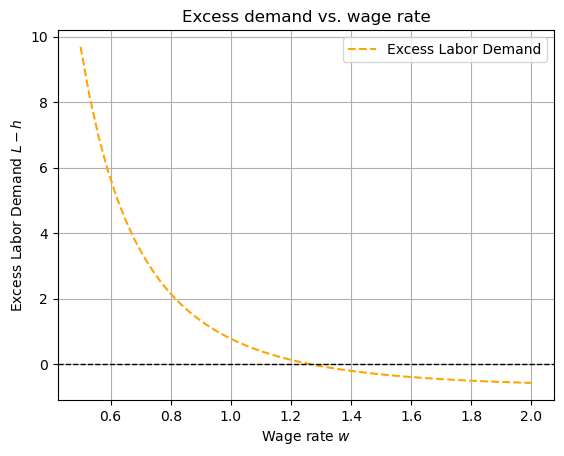

In [49]:
ex_demand_grid = np.array([compute_labor_ex_demand(w, par) for w in wages])
plt.plot(wages, ex_demand_grid, c='orange', ls='--', lw=1.5, label='Excess Labor Demand')
plt.xlabel('Wage rate $w$')
plt.ylabel('Excess Labor Demand $L - h$')
plt.title('Excess demand vs. wage rate')
plt.axhline(0.0, ls='--', lw=1, color='k')
plt.grid()
_ = plt.legend()

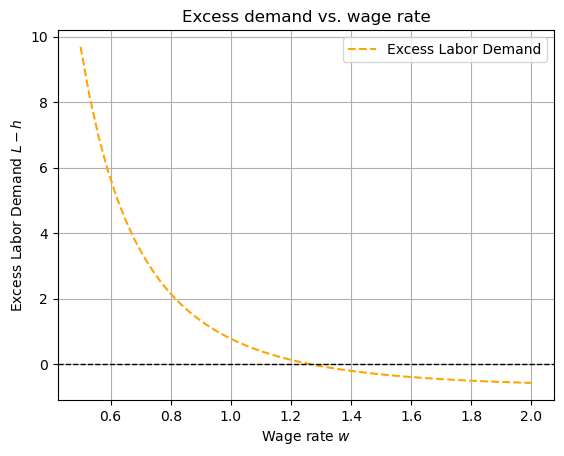

In [ ]:
wages = np.linspace(.5, 2, 51)
ex_demand_grid = np.empty_like(wages)

# Could also just do np.array with list comprehension inside!
for i, w in enumerate(wages):
    ex_demand = compute_labor_ex_demand(w, par)
    ex_demand_grid[i] = ex_demand

plt.plot(wages, ex_demand_grid, c='orange', ls='--', lw=1.5, label='Excess Labor Demand')
plt.xlabel('Wage rate $w$')
plt.ylabel('Excess Labor Demand $L - h$')
plt.title('Excess demand vs. wage rate')
plt.axhline(0.0, ls='--', lw=1, color='k')
plt.grid()
_ = plt.legend()

##### Step 5: Call root finder to find equilibrium

- Use 
[`root_scalar()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html)
- Use `method='newton'` and specify initial value `x0`

In [45]:
from scipy.optimize import root_scalar

res = root_scalar(
    compute_labor_ex_demand, 
    method='newton', 
    x0=1.0,
    args=(par, )
)

In [46]:
res

      converged: True
           flag: converged
 function_calls: 18
     iterations: 9
           root: 1.2643421152949206
         method: newton

##### Step 6: Compute remaining equilibrium quantities

- Use `Equilibrium` definition to store quantities and prices
- Compute equilibrium using `compute_equilibrium()` from [`lecture06_labor`](lecture06_labor.py) module
- Print equilibrium using `print_equilibrium()` from [`lecture06_labor`](lecture06_labor.py) module

In [47]:
from dataclasses import dataclass


@dataclass
class Equilibrium:
    """
    Container to store equilibrium allocations and prices.
    """

    par: Parameters = None  # Parameters used to compute equilibrium
    c: float = None  # Optimal consumption
    h: float = None  # Optimal hours
    r: float = None  # Interest rate
    w: float = None  # Wage rate
    L: float = None  # Labor demand
    K: float = None  # Capital demand
    Y: float = None  # Output

In [48]:
# Import helper functions from module
from lecture06_labor import compute_equilibrium, print_equilibrium

# Compute equilibrium, return Equilibrium object
eq = compute_equilibrium(par)

# Print equilibrium allocation and prices
print_equilibrium(eq)

Equilibrium:
  Households:
    c = 1.49042
    h = 0.75444
  Firms:
    Y = 1.49042
    L = 0.75444
    K = 5.00000
  Prices:
    r = 0.10731
    w = 1.26434
  Market clearing:
    Labor market: -5.36773e-11
    Goods market: 6.78662e-11


***
### Comparative statics

#### Compute equilibrium for different parameter values

- How do equilibrium prices & quantities depend on $a$?


<div style="background-color: #c6dbef; color: #363636; padding: 0.8em 1em 0.5em 1em; border: 1pt solid #363636;">
<h3 style="font-weight: bold;">Your turn</h3>

<ol>
    <li>Use the function <TT>compute_equilibrium()</TT> to evaluate the equilibria for N=30 different
values of <i>a</i> on the interval [1, 10] and store them in the list <TT>equilibria</TT>.</li>
    <li>How can you check that the algorithm returned something sensible for all <i>a</i>?</li>
</ol>

</div>
<span style="display: none;">YourTurnEnd</span>

#### Plot equilibrium quantities and prices

In [ ]:
# Convert equilibrium data to arrays:
# Use the list equilibria you computed above.
c_eq_grid = np.array([eq.c for eq in equilibria])
h_eq_grid = np.array([eq.h for eq in equilibria])
w_eq_grid = np.array([eq.w for eq in equilibria])
r_eq_grid = np.array([eq.r for eq in equilibria])

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(6, 5), sharex=True, constrained_layout=True)

ax[0, 0].plot(a_grid, r_eq_grid)
ax[0, 0].set_title('Interest rate $r$')

ax[0, 1].plot(a_grid, w_eq_grid)
ax[0, 1].set_title('Wage rate $w$')

ax[1, 0].plot(a_grid, c_eq_grid)
ax[1, 0].set_xlabel('Capital stock $K = a$')
ax[1, 0].set_title('Consumption $c$')

ax[1, 1].plot(a_grid, h_eq_grid)
ax[1, 1].set_xlabel('Capital stock $K = a$')
ax[1, 1].set_title('Labor supply $h$')

_ = fig.suptitle('Equilibrium allocations and prices', fontsize=12)